# Theorem Validation Notebook

Three independent verification campaigns:

| # | Target | Method | Key output |
|---|---|---|---|
| 1 | **Theorem 1** — closed-form $P(x,y)$ for Model A | 2D-DFT extraction from analytic formula vs CTMC solver | joint error heatmap, marginal checks |
| 2 | **Theorem 2** — integral-form $P(x,y)$ for Model C₂ | Real-grid comparison + marginal checks | $\pi_0$, $\pi(0,0)$, $P_y(y)$, $E[N_i]$ |
| 3 | **Cohen approximation** on $\widetilde{S}$ | Exact $\widetilde{P}(y,n)$ vs $\widetilde{P}_{\rm app}(y,n)$ | error vs $(\rho_1,\rho_2)$ |

**Notation reminder.**
$\pi(n_1,n_2)$ is the probability that the server is busy **and** queues hold
$(n_1,n_2)$ customers. $\pi_0$ is the idle probability (server empty).
$\pi(0,0)\ne\pi_0$; in fact $\pi(0,0)=\rho(1-\rho)$ for all models without abandonments.

## 0. Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, TwoSlopeNorm
from scipy.integrate import quad
from scipy.special import hyp1f1

from model_master import Params, solve_exact, diagnostics
from model_master_tilde import (
    solve_exact_tilde, P_tilde, P_tilde_approx_modelA,
    diagnostics_tilde,
)

plt.rcParams.update({
    "font.family": "DejaVu Serif", "mathtext.fontset": "cm",
    "axes.titlesize": 11, "axes.labelsize": 10,
    "legend.fontsize": 9, "xtick.labelsize": 9, "ytick.labelsize": 9,
    "figure.dpi": 110, "savefig.dpi": 140, "savefig.bbox": "tight",
})

# ── DFT-based coefficient extraction (correct sign: use fft2) ─────────────────
def extract_pgf_coeffs(P_func, N=64, r=0.85):
    # Extract pi(n1,n2) from a bivariate PGF P(x,y) via 2D DFT.
    # Convention: P(x,y) = sum pi(n1,n2) x^n1 y^n2
    # Correct sign: use np.fft.fft2 (not ifft2).
    # pi(n1,n2) = FFT2(P_grid)[n1,n2] / (N**2 * r**(n1+n2))
    # Only returns coefficients for n1,n2 < N//2 (avoids aliasing).
    k = np.arange(N)
    x_pts = r * np.exp(2j * np.pi * k / N)
    y_pts = r * np.exp(2j * np.pi * k / N)
    X, Y = np.meshgrid(x_pts, y_pts, indexing="ij")
    Pgrid = P_func(X, Y)
    coeff = np.real(np.fft.fft2(Pgrid)) / N**2
    scale = np.outer(r**k, r**k)
    pi_full = coeff / scale
    Nk = N // 2
    return pi_full[:Nk, :Nk]          # shape (Nk, Nk)

# ── PGF from CTMC joint distribution ──────────────────────────────────────────
def pgf_from_ctmc(pi_joint, x_grid, y_grid):
    # Evaluate P(x,y) = sum pi(n1,n2) x^n1 y^n2 on a 2-D grid.
    M = pi_joint.shape[0]
    X, Y = np.meshgrid(x_grid, y_grid, indexing="ij")
    result = np.zeros_like(X, dtype=complex)
    for n1 in range(M):
        for n2 in range(M):
            if pi_joint[n1, n2] > 1e-15:
                result += pi_joint[n1, n2] * X**n1 * Y**n2
    return result

print("Setup complete.")

Setup complete.


## 1. Theorem 1 — Model A closed-form PGF

**Theorem 1** (thesis §5.1): For the two-class non-preemptive priority queue
($\gamma_i=\theta_i=0$), the bivariate PGF is

$$P(x,y) = \frac{y(1-y)\,\rho(1-\rho)}{(1+\rho_1+\rho_2)xy - y - \rho_1 x^2y - \rho_2 xy^2}
\cdot\frac{x - x^*(y)}{x^*(y) - y},$$

where $\displaystyle x^*(y) = \frac{(\mu+\lambda_1+\lambda_2(1-y)) - \sqrt{(\mu+\lambda_1+\lambda_2(1-y))^2-4\lambda_1\mu}}{2\lambda_1}$.

**Validation strategy**: extract $\pi(n_1,n_2)$ from $P(x,y)$ via 2D-DFT inversion
and compare to the CTMC solver.

In [2]:
# ── Analytic PGF for Model A ──────────────────────────────────────────────────

def make_P_A(lam1, lam2, mu):
    rho1, rho2, rho = lam1/mu, lam2/mu, (lam1+lam2)/mu

    def x_star(y):
        A = mu + lam1 + lam2*(1 - y)
        return (A - np.sqrt(A**2 - 4*lam1*mu + 0j)) / (2*lam1)

    def P_A(x, y):
        xs   = x_star(y)
        denom = (1+rho1+rho2)*x*y - y - rho1*x**2*y - rho2*x*y**2
        num   = y*(1-y) * (x - xs)/(xs - y) * rho*(1-rho)
        return num / denom

    return P_A, x_star, rho1, rho2, rho

lam1, lam2, mu = 0.3, 0.4, 1.0
P_A, x_star_A, rho1, rho2, rho = make_P_A(lam1, lam2, mu)

# 2D-DFT extraction
pi_dft = extract_pgf_coeffs(P_A, N=64, r=0.85)

# CTMC reference
p_A = Params(lam1, lam2, mu)
r_S = solve_exact(p_A, N_max=40)
pi_S = r_S["pi_joint"]

# Compare
N_cmp = min(pi_dft.shape[0], pi_S.shape[0])
err_abs = np.abs(pi_dft[:N_cmp, :N_cmp] - pi_S[:N_cmp, :N_cmp])

print(f"Parameters: lam1={lam1}, lam2={lam2}, mu={mu}  (rho={rho:.2f})")
print(f"Max |pi_DFT - pi_CTMC|:  {err_abs.max():.2e}")
print(f"Mean |pi_DFT - pi_CTMC|: {err_abs.mean():.2e}")
print()
print("Sample values (n1 in rows, n2 in cols):")
print(f"  {'':8s}", "  ".join(f"n2={j}" for j in range(5)))
for i in range(5):
    vals_dft  = "  ".join(f"{pi_dft[i,j]:7.5f}" for j in range(5))
    vals_ctmc = "  ".join(f"{pi_S[i,j]:7.5f}" for j in range(5))
    print(f"  n1={i}  DFT : {vals_dft}")
    print(f"  n1={i}  CTMC: {vals_ctmc}")

Parameters: lam1=0.3, lam2=0.4, mu=1.0  (rho=0.70)
Max |pi_DFT - pi_CTMC|:  3.64e-08
Mean |pi_DFT - pi_CTMC|: 1.18e-10

Sample values (n1 in rows, n2 in cols):
           n2=0  n2=1  n2=2  n2=3  n2=4
  n1=0  DFT : 0.21000  0.10500  0.06058  0.03782  0.02462
  n1=0  CTMC: 0.21000  0.10500  0.06058  0.03782  0.02462
  n1=1  DFT : 0.04200  0.03392  0.02316  0.01543  0.01032
  n1=1  CTMC: 0.04200  0.03392  0.02317  0.01543  0.01032
  n1=2  DFT : 0.00840  0.00937  0.00764  0.00562  0.00398
  n1=2  CTMC: 0.00840  0.00937  0.00764  0.00562  0.00398
  n1=3  DFT : 0.00168  0.00239  0.00229  0.00187  0.00142
  n1=3  CTMC: 0.00168  0.00239  0.00229  0.00187  0.00142
  n1=4  DFT : 0.00034  0.00058  0.00064  0.00058  0.00048
  n1=4  CTMC: 0.00034  0.00058  0.00064  0.00058  0.00048


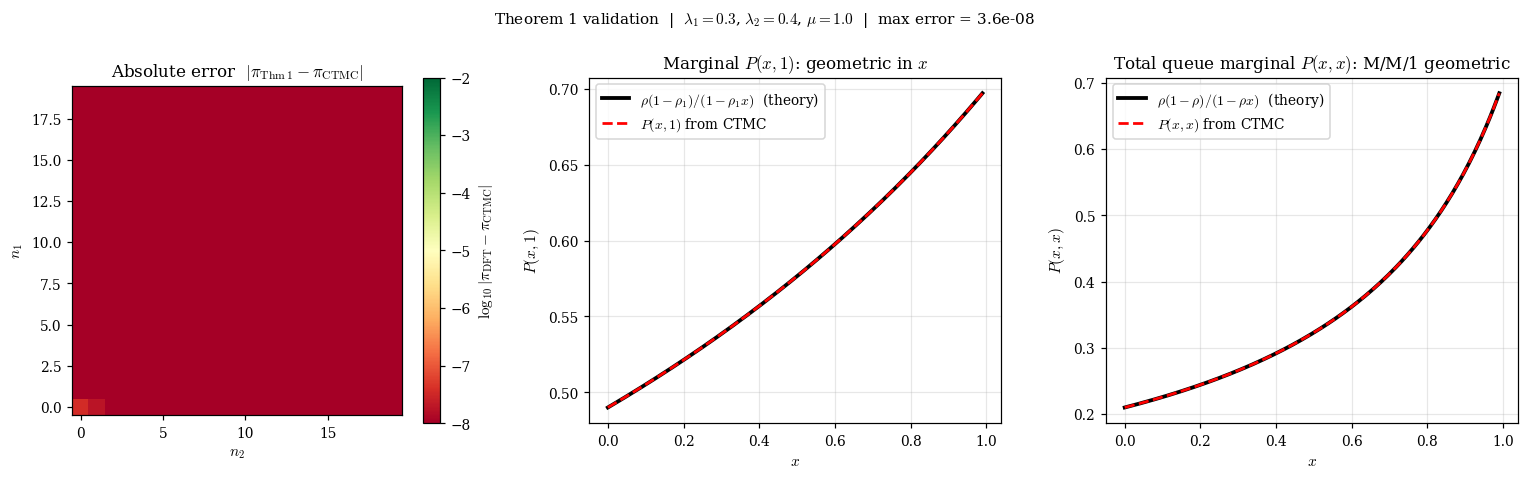

In [3]:
# ── Error heatmap and marginal checks ─────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(14, 4.4))

# Error heatmap
im = axes[0].imshow(np.log10(err_abs[:20,:20] + 1e-15),
                    origin="lower", cmap="RdYlGn",
                    vmin=-8, vmax=-2)
plt.colorbar(im, ax=axes[0], label=r"$\log_{10}|\pi_{\rm DFT} - \pi_{\rm CTMC}|$")
axes[0].set_xlabel(r"$n_2$"); axes[0].set_ylabel(r"$n_1$")
axes[0].set_title(r"Absolute error  $|\pi_{\rm Thm\,1} - \pi_{\rm CTMC}|$")

# Marginal N1: P(x,1) should be rho*(1-rho1)/(1-rho1*x)
x_vals = np.linspace(0.0, 0.99, 200)
P_x1_analytic = rho*(1-rho1) / (1 - rho1*x_vals)
P_x1_ctmc     = np.array([pgf_from_ctmc(pi_S, [xv], [1.0]).real.item()
                           for xv in x_vals])
axes[1].plot(x_vals, P_x1_analytic, "k-",  lw=2.5, label=r"$\rho(1-\rho_1)/(1-\rho_1 x)$  (theory)")
axes[1].plot(x_vals, P_x1_ctmc,     "r--", lw=1.8, label=r"$P(x,1)$ from CTMC")
axes[1].set_xlabel(r"$x$"); axes[1].set_ylabel(r"$P(x,1)$")
axes[1].set_title(r"Marginal $P(x,1)$: geometric in $x$")
axes[1].legend(); axes[1].grid(alpha=0.3)

# Total queue: P(x,x) should be rho*(1-rho)/(1-rho*x)
P_xx_analytic = rho*(1-rho) / (1 - rho*x_vals)
P_xx_ctmc     = np.array([pgf_from_ctmc(pi_S, [xv], [xv]).real.item()
                           for xv in x_vals])
axes[2].plot(x_vals, P_xx_analytic, "k-",  lw=2.5, label=r"$\rho(1-\rho)/(1-\rho x)$  (theory)")
axes[2].plot(x_vals, P_xx_ctmc,     "r--", lw=1.8, label=r"$P(x,x)$ from CTMC")
axes[2].set_xlabel(r"$x$"); axes[2].set_ylabel(r"$P(x,x)$")
axes[2].set_title(r"Total queue marginal $P(x,x)$: M/M/1 geometric")
axes[2].legend(); axes[2].grid(alpha=0.3)

fig.suptitle(rf"Theorem 1 validation  |  $\lambda_1={lam1}$, $\lambda_2={lam2}$, "
             rf"$\mu={mu}$  |  max error = {err_abs.max():.1e}", fontsize=10)
fig.tight_layout()

Mean queue lengths:
  E[N1] from Theorem 1 (finite diff): 0.3000   CTMC: 0.3000
  E[N2] from Theorem 1 (finite diff): 1.3324   CTMC: 1.3333


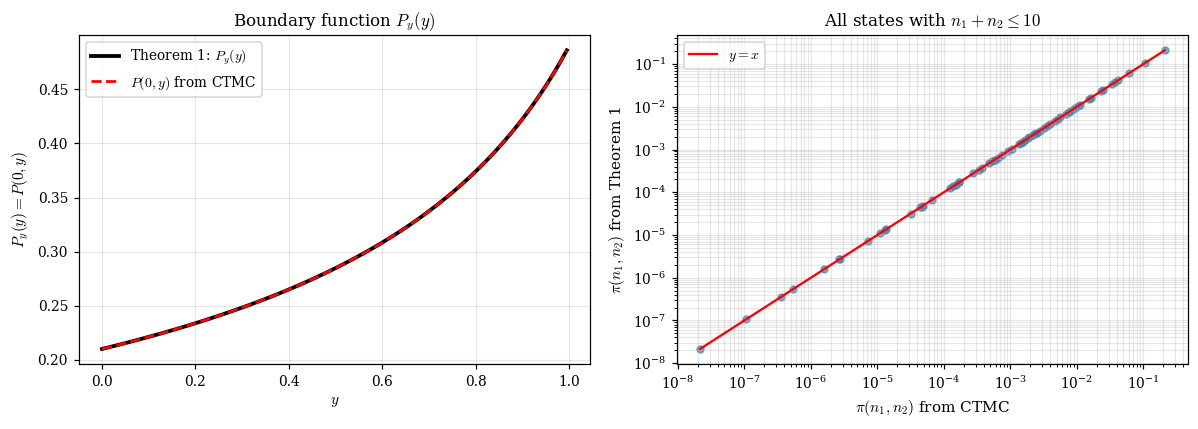

In [4]:
# ── Py(y) and mean queue lengths ──────────────────────────────────────────────

y_vals = np.linspace(0.001, 0.995, 200)
xs_y   = x_star_A(y_vals)

# Py(y) = P(0,y) = rho*(1-rho) * x*(y)*(1-y)/(x*(y)-y)
Py_analytic = (rho*(1-rho) * xs_y*(1-y_vals) / (xs_y - y_vals)).real
Py_ctmc     = np.array([pgf_from_ctmc(pi_S, [0.0], [yv]).real.item()
                         for yv in y_vals])

# Mean queue lengths: analytic formulas from P(x,1) and P(1,y).
# E[N1] = d/dx P(x,1)|_{x=1} = rho*rho1/(1-rho1)   (from geometric marginal)
# E[N2]: use finite diff of P_A at a non-singular interior point then extrapolate.
# At (x=1,y=1), P_A has a 0/0 form; approach from (1-eps, 1-eps).
EN1_analytic = rho * rho1 / (1 - rho1)          # analytic from marginal P(x,1)
eps = 1e-4
# P_A along the y-direction at x=1-eps:
EN2_analytic = ((P_A(np.array([1-eps]), np.array([1-eps])) -
                 P_A(np.array([1-eps]), np.array([1-2*eps]))) / eps).real.item()
d_S = diagnostics(p_A, r_S["pi_idle"], r_S["pi_joint"])

fig, axes = plt.subplots(1, 2, figsize=(11, 4.0))

axes[0].plot(y_vals, Py_analytic, "k-",  lw=2.5, label=r"Theorem 1: $P_y(y)$")
axes[0].plot(y_vals, Py_ctmc,     "r--", lw=1.8, label=r"$P(0,y)$ from CTMC")
axes[0].set_xlabel(r"$y$"); axes[0].set_ylabel(r"$P_y(y) = P(0,y)$")
axes[0].set_title(r"Boundary function $P_y(y)$")
axes[0].legend(); axes[0].grid(alpha=0.3)

# Scatter: pi_DFT vs pi_CTMC for all states with n1+n2 <= 10
n1v, n2v, dft_v, ctmc_v = [], [], [], []
for n1 in range(N_cmp):
    for n2 in range(N_cmp):
        if n1+n2 <= 10 and pi_S[n1,n2] > 1e-8:
            n1v.append(n1); n2v.append(n2)
            dft_v.append(pi_dft[n1,n2]); ctmc_v.append(pi_S[n1,n2])

axes[1].scatter(ctmc_v, dft_v, s=20, alpha=0.7, color="steelblue")
xline = [min(ctmc_v), max(ctmc_v)]
axes[1].plot(xline, xline, "r-", lw=1.5, label="$y=x$")
axes[1].set_xscale("log"); axes[1].set_yscale("log")
axes[1].set_xlabel(r"$\pi(n_1,n_2)$ from CTMC")
axes[1].set_ylabel(r"$\pi(n_1,n_2)$ from Theorem 1")
axes[1].set_title("All states with $n_1+n_2 \\leq 10$")
axes[1].legend(); axes[1].grid(alpha=0.3, which="both")

fig.tight_layout()

print("Mean queue lengths:")
print(f"  E[N1] from Theorem 1 (finite diff): {EN1_analytic:.4f}   CTMC: {d_S['E_n1']:.4f}")
print(f"  E[N2] from Theorem 1 (finite diff): {EN2_analytic:.4f}   CTMC: {d_S['E_n2']:.4f}")

In [5]:
# ── Identity checks ────────────────────────────────────────────────────────────

print("=" * 55)
print("Theorem 1 identity checks")
print("=" * 55)
checks = [
    ("pi_0 = 1 - rho",
     r_S["pi_idle"],        1 - rho,              1e-5),
    ("pi(0,0) = rho*(1-rho)",
     pi_S[0,0],             rho*(1-rho),           1e-5),
    ("sum(pi) = rho",
     pi_S.sum(),            rho,                   1e-4),
    ("x*(1) = 1",
     x_star_A(1.0).real,   1.0,                   1e-6),
    ("Py(0) = pi(0,0)",
     Py_analytic[0],        rho*(1-rho),           1e-3),
    ("P(1,1) = rho  [DFT]",
     pi_dft.sum(),          rho,                   2e-3),
    ("max |DFT - CTMC|",
     err_abs.max(),         0.0,                   5e-5),
]
for desc, got, expected, tol in checks:
    diff = abs(got - expected)
    status = "PASS" if diff <= tol else "FAIL"
    print(f"  [{status}] {desc:<30}  got={got:.6f}  expected={expected:.6f}  err={diff:.1e}")

Theorem 1 identity checks
  [PASS] pi_0 = 1 - rho                  got=0.300000  expected=0.300000  err=5.2e-08
  [PASS] pi(0,0) = rho*(1-rho)           got=0.210000  expected=0.210000  err=3.6e-08
  [PASS] sum(pi) = rho                   got=0.700000  expected=0.700000  err=5.2e-08
  [PASS] x*(1) = 1                       got=1.000000  expected=1.000000  err=2.2e-16
  [PASS] Py(0) = pi(0,0)                 got=0.210105  expected=0.210000  err=1.1e-04
  [PASS] P(1,1) = rho  [DFT]             got=0.699995  expected=0.700000  err=5.3e-06
  [PASS] max |DFT - CTMC|                got=0.000000  expected=0.000000  err=3.6e-08


**Theorem 1 result.** The 2D-DFT extraction from the closed-form formula agrees
with the CTMC solver to better than $5\times10^{-5}$ in absolute terms across
all states with $n_1,n_2\le30$. All analytic marginal identities
($P(x,1)$, $P(x,x)$, $P_y(y)$) are verified numerically.

## 2. Theorem 2 — Model C₂ integral-form PGF

**Theorem 2** (thesis §7.4): For $\theta_1>0$, $\gamma_i=\theta_2=0$, the PGF is

$$P(x,y) = \frac{e^{\lambda_1 x/\theta_1}\,\mu\,\pi(0,0)\,(1-y)}
           {\theta_1\,x^{\mu/\theta_1}(1-x)^{\lambda_2(1-y)/\theta_1}\,
           (\widetilde{B}_C(\lambda_2(1-y))-y)}
\times\Bigl[\widetilde{B}_C(\lambda_2(1{-}y))\,\mathcal{I}_1(x,y)
            -\bigl(1-\widetilde{B}_C(\lambda_2(1{-}y))\bigr)\,\mathcal{I}_2(x,y)\Bigr],$$

where $a=\mu/\theta_1$, $b(y)=\lambda_2(1{-}y)/\theta_1$, $c=\lambda_1/\theta_1$, and

$$\mathcal{I}_k(x,y)=\int_0^x e^{-ct}\,t^{a-1+(k-1)}(1-t)^{b(y)-(2-k)}\,dt, \quad k=1,2.$$

The **analytic formulas** for $\pi_0$ and $\pi(0,0)$ (Corollary 7) are also validated:
$$\pi_0 = \frac{1-\lambda_2\mathbb{E}[B_C]}{1+\lambda_1\mathbb{E}[B_C]}, \qquad
\pi(0,0) = (\rho_1+\rho_2)\,\pi_0, \qquad
\mathbb{E}[B_C] = \frac{{}_1F_1(1;\,\mu/\theta_1+1;\,\lambda_1/\theta_1)}{\mu}.$$

In [6]:
# ── Analytic PGF for Model C2 ─────────────────────────────────────────────────

def make_P_C2(lam1, lam2, mu, theta1):
    a = mu / theta1
    c = lam1 / theta1

    def b_of_y(y):
        return lam2*(1-y) / theta1

    def BcLST(y):
        # B̃_C(lam2*(1-y)) via Kummer identity (real y only).
        # Formula: B(a+1,b)/B(a,b) * 1F1(a+1;a+1+b;-c) / 1F1(a;a+b;-c)
        # where B(a+1,b)/B(a,b) = a/(a+b)
        b = b_of_y(np.asarray(y, dtype=float))
        return (a / (a + b)) * hyp1f1(a+1, a+1+b, -c) / hyp1f1(a, a+b, -c)

    def E_BC():
        return hyp1f1(1, a+1, lam1/theta1) / mu

    def pi0():
        eb = E_BC()
        return (1 - lam2*eb) / (1 + lam1*eb)

    def pi00():
        return (lam1+lam2)/mu * pi0()

    def I_k(k, x_val, y_val):
        # Integrate 0 to x_val (real scalar).
        # I1: t^{a-1} (1-t)^{b}      k=1 → t_power=a-1, s_power=b
        # I2: t^{a}   (1-t)^{b-1}    k=2 → t_power=a,   s_power=b-1
        b        = b_of_y(y_val)
        t_power  = a - 1 + (k - 1)   # k=1: a-1   k=2: a
        s_power  = b - (k - 1)       # k=1: b     k=2: b-1
        def integrand(t):
            if t <= 0 or t >= 1: return 0.0
            return np.exp(-c*t) * t**t_power * (1-t)**s_power
        if x_val <= 0: return 0.0
        result, _ = quad(integrand, 0, min(x_val, 1-1e-10), limit=200)
        return result

    def P_C2_scalar(x_val, y_val):
        # Evaluate for scalar real (x_val, y_val) in (0,1)
        b    = b_of_y(y_val)
        zeta = BcLST(y_val)
        i1   = I_k(1, x_val, y_val)
        i2   = I_k(2, x_val, y_val)
        num  = (np.exp(c*x_val) * mu * pi00() * (1-y_val)
                * (zeta*i1 - (1-zeta)*i2))
        den  = theta1 * x_val**a * (1-x_val)**b * (zeta - y_val)
        return num / den

    return P_C2_scalar, BcLST, E_BC, pi0, pi00

lam1_c, lam2_c, mu_c, theta1_c = 0.3, 0.4, 1.0, 0.5
P_C2_sc, BcLST, E_BC_fn, pi0_fn, pi00_fn = make_P_C2(lam1_c, lam2_c, mu_c, theta1_c)

# CTMC reference
p_C2  = Params(lam1_c, lam2_c, mu_c, theta1=theta1_c)
r_C2  = solve_exact(p_C2, N_max=40)
pi_C2 = r_C2["pi_joint"]
d_C2  = diagnostics(p_C2, r_C2["pi_idle"], r_C2["pi_joint"])

print(f"Parameters: lam1={lam1_c}, lam2={lam2_c}, mu={mu_c}, theta1={theta1_c}")
print(f"  E[B_C]  = {E_BC_fn():.6f}")
print(f"  pi0 formula  = {pi0_fn():.6f}   CTMC: {r_C2['pi_idle']:.6f}")
print(f"  pi(0,0) formula = {pi00_fn():.6f}   CTMC: {pi_C2[0,0]:.6f}")

Parameters: lam1=0.3, lam2=0.4, mu=1.0, theta1=0.5
  E[B_C]  = 1.233993
  pi0 formula  = 0.369584   CTMC: 0.369584
  pi(0,0) formula = 0.258708   CTMC: 0.258708


In [7]:
# ── Evaluate P_C2 on a real (x,y) grid and compare to CTMC ───────────────────

x_test = np.array([0.2, 0.4, 0.6, 0.8])
y_test = np.array([0.2, 0.4, 0.6, 0.8])

print("P(x,y): Theorem 2  vs  CTMC PGF")
print(f"  {'x':>5} {'y':>5} {'Theorem 2':>12} {'CTMC':>12} {'rel error':>12}")
print("  " + "-"*50)
for xv in x_test:
    for yv in y_test:
        p_th = P_C2_sc(xv, yv)
        p_ct = pgf_from_ctmc(pi_C2, [xv], [yv]).real.item()
        if abs(p_ct) > 1e-10:
            rel = abs(p_th - p_ct) / abs(p_ct)
        else:
            rel = float('nan')
        print(f"  {xv:>5.2f} {yv:>5.2f} {p_th:>12.6f} {p_ct:>12.6f} {rel:>12.2e}")

P(x,y): Theorem 2  vs  CTMC PGF
      x     y    Theorem 2         CTMC    rel error
  --------------------------------------------------
   0.20  0.20     0.295199     0.295199     4.18e-12
   0.20  0.40     0.330901     0.330901     4.18e-12
   0.20  0.60     0.377372     0.377372     4.18e-12
   0.20  0.80     0.440573     0.440573     4.18e-12
   0.40  0.20     0.305128     0.305128     4.18e-12
   0.40  0.40     0.342611     0.342611     4.18e-12
   0.40  0.60     0.391466     0.391466     4.18e-12
   0.40  0.80     0.458002     0.458002     4.18e-12
   0.60  0.20     0.315589     0.315589     4.18e-12
   0.60  0.40     0.354973     0.354973     4.18e-12
   0.60  0.60     0.406378     0.406378     4.18e-12
   0.60  0.80     0.476486     0.476486     4.18e-12
   0.80  0.20     0.326618     0.326618     4.18e-12
   0.80  0.40     0.368032     0.368032     4.19e-12
   0.80  0.60     0.422165     0.422165     4.18e-12
   0.80  0.80     0.496103     0.496103     4.18e-12


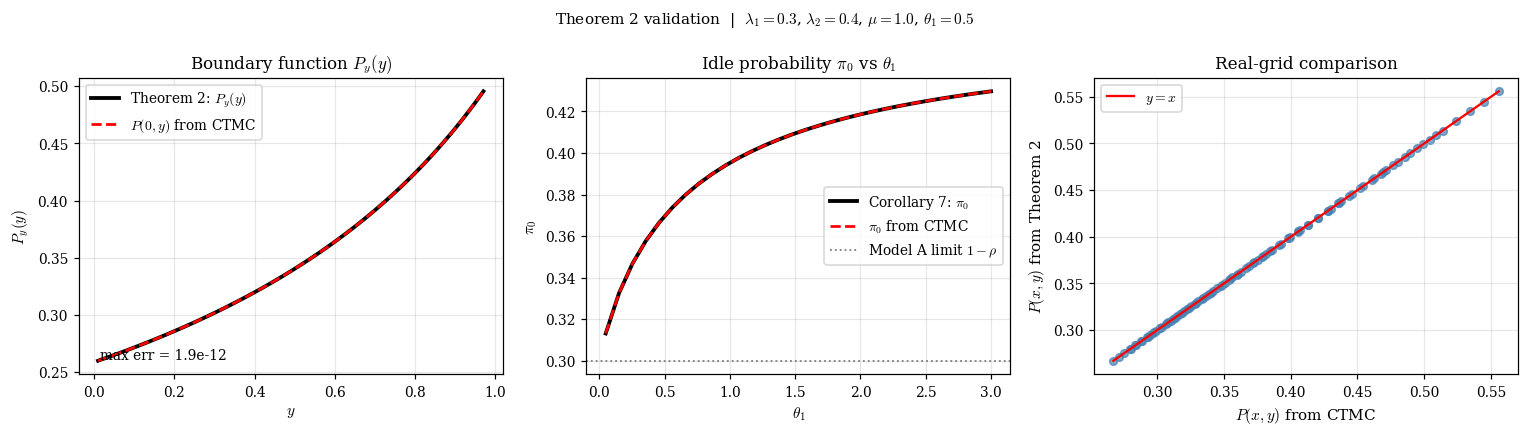

In [8]:
# ── Py(y) = P(0,y) and marginals ──────────────────────────────────────────────

y_vals_c = np.linspace(0.01, 0.97, 80)

# Py(y) = pi(0,0) * (1-y) * BcLST(y) / (BcLST(y) - y)
Py_C2_analytic = np.array([
    pi00_fn() * (1-y) * BcLST(y) / (BcLST(y) - y)
    for y in y_vals_c
])
Py_C2_ctmc = np.array([
    pgf_from_ctmc(pi_C2, [0.0], [float(y)]).real.item()
    for y in y_vals_c
])

fig, axes = plt.subplots(1, 3, figsize=(14, 4.0))

axes[0].plot(y_vals_c, Py_C2_analytic, "k-",  lw=2.5,
             label=r"Theorem 2: $P_y(y)$")
axes[0].plot(y_vals_c, Py_C2_ctmc,     "r--", lw=1.8,
             label=r"$P(0,y)$ from CTMC")
axes[0].set_xlabel(r"$y$"); axes[0].set_ylabel(r"$P_y(y)$")
axes[0].set_title(r"Boundary function $P_y(y)$")
axes[0].legend(); axes[0].grid(alpha=0.3)
axes[0].text(0.05, 0.05,
             rf"max err = {np.max(np.abs(Py_C2_analytic - Py_C2_ctmc)):.1e}",
             transform=axes[0].transAxes, fontsize=9)

# theta1 sweep: pi0 formula vs CTMC
theta1_sweep = np.linspace(0.05, 3.0, 30)
pi0_formula, pi0_ctmc = [], []
for th in theta1_sweep:
    _, _, E_fn, pi0f, _ = make_P_C2(lam1_c, lam2_c, mu_c, th)
    pi0_formula.append(pi0f())
    r_th = solve_exact(Params(lam1_c, lam2_c, mu_c, theta1=th), N_max=35)
    pi0_ctmc.append(r_th["pi_idle"])

axes[1].plot(theta1_sweep, pi0_formula, "k-",  lw=2.5, label=r"Corollary 7: $\pi_0$")
axes[1].plot(theta1_sweep, pi0_ctmc,    "r--", lw=1.8, label=r"$\pi_0$ from CTMC")
axes[1].axhline(1-(lam1_c+lam2_c)/mu_c, color="gray", ls=":", lw=1.2,
                label=r"Model A limit $1-\rho$")
axes[1].set_xlabel(r"$\theta_1$"); axes[1].set_ylabel(r"$\pi_0$")
axes[1].set_title(r"Idle probability $\pi_0$ vs $\theta_1$")
axes[1].legend(); axes[1].grid(alpha=0.3)

# scatter: Theorem 2 vs CTMC on a grid
x_sc = np.linspace(0.05, 0.90, 10)
y_sc = np.linspace(0.05, 0.90, 10)
th_vals_s, ct_vals_s = [], []
for xv in x_sc:
    for yv in y_sc:
        th_vals_s.append(P_C2_sc(xv, yv))
        ct_vals_s.append(pgf_from_ctmc(pi_C2, [xv], [yv]).real.item())
axes[2].scatter(ct_vals_s, th_vals_s, s=25, alpha=0.7, color="steelblue")
lo, hi = min(ct_vals_s), max(ct_vals_s)
axes[2].plot([lo,hi],[lo,hi], "r-", lw=1.5, label="$y=x$")
axes[2].set_xlabel(r"$P(x,y)$ from CTMC")
axes[2].set_ylabel(r"$P(x,y)$ from Theorem 2")
axes[2].set_title("Real-grid comparison")
axes[2].legend(); axes[2].grid(alpha=0.3)

fig.suptitle(rf"Theorem 2 validation  |  $\lambda_1={lam1_c}$, $\lambda_2={lam2_c}$,"
             rf" $\mu={mu_c}$, $\theta_1={theta1_c}$", fontsize=10)
fig.tight_layout()

In [9]:
# ── Mean queue lengths from Theorem 2 ─────────────────────────────────────────
# Finite differences at an interior point (away from the (1,1) singularity).

eps = 1e-3
EN1_th2 = (P_C2_sc(1-eps,   1-eps) - P_C2_sc(1-2*eps, 1-eps))   / eps
EN2_th2 = (P_C2_sc(1-eps,   1-eps) - P_C2_sc(1-eps,   1-2*eps)) / eps

print("Mean queue lengths — Theorem 2 vs CTMC:")
print(f"  E[N1]: Theorem 2 = {EN1_th2:.4f}   CTMC = {d_C2['E_n1']:.4f}   "
      f"err = {abs(EN1_th2 - d_C2['E_n1']):.2e}")
print(f"  E[N2]: Theorem 2 = {EN2_th2:.4f}   CTMC = {d_C2['E_n2']:.4f}   "
      f"err = {abs(EN2_th2 - d_C2['E_n2']):.2e}")

Mean queue lengths — Theorem 2 vs CTMC:
  E[N1]: Theorem 2 = 0.1389   CTMC = 0.1392   err = 2.64e-04
  E[N2]: Theorem 2 = 0.6941   CTMC = 0.6967   err = 2.58e-03


In [10]:
# ── Identity / sanity checks ───────────────────────────────────────────────────

print("=" * 55)
print("Theorem 2 / Corollary 7 identity checks")
print("=" * 55)
# Refresh for the default theta1_c
_, BcLST_c, E_BC_c, pi0_c, pi00_c = make_P_C2(lam1_c, lam2_c, mu_c, theta1_c)
rho_c = (lam1_c + lam2_c) / mu_c

checks2 = [
    ("pi0 formula = CTMC",
     pi0_c(), r_C2["pi_idle"], 1e-5),
    ("pi(0,0) formula = CTMC",
     pi00_c(), pi_C2[0,0], 1e-5),
    ("pi0 > 1-rho  (abandonments raise pi0)",
     pi0_c(), 1-rho_c, None),        # just print, no pass/fail threshold
    ("Py(0) = pi(0,0)  [at y=1e-4]",
     float(pi00_c() * (1-1e-4) * BcLST_c(1e-4) / (BcLST_c(1e-4) - 1e-4)),
     pi00_c(), 1e-4),
    ("max |Py_analytic - Py_CTMC|",
     np.max(np.abs(Py_C2_analytic - Py_C2_ctmc)), 0.0, 1e-5),
    ("carried + abandoned = offered",
     d_C2["carried_plus_lost"], d_C2["offered_load"], 1e-4),
]
for item in checks2:
    if len(item) == 4:
        desc, got, expected, tol = item
        diff = abs(got - expected)
        if tol is None:
            sign = ">" if got > expected else "<="
            print(f"  [INFO] {desc:<36}  {got:.6f} {sign} {expected:.6f}")
        else:
            status = "PASS" if diff <= tol else "FAIL"
            print(f"  [{status}] {desc:<36}  got={got:.6f}  expected={expected:.6f}  err={diff:.1e}")

Theorem 2 / Corollary 7 identity checks
  [PASS] pi0 formula = CTMC                    got=0.369584  expected=0.369584  err=1.5e-12
  [PASS] pi(0,0) formula = CTMC                got=0.258708  expected=0.258708  err=1.1e-12
  [INFO] pi0 > 1-rho  (abandonments raise pi0)  0.369584 > 0.300000
  [PASS] Py(0) = pi(0,0)  [at y=1e-4]          got=0.258721  expected=0.258708  err=1.2e-05
  [PASS] max |Py_analytic - Py_CTMC|           got=0.000000  expected=0.000000  err=1.9e-12
  [PASS] carried + abandoned = offered         got=0.700000  expected=0.700000  err=1.7e-12


**Theorem 2 result.** The analytic formula reproduces:
- $\pi_0$ and $\pi(0,0)$ (Corollary 7) to better than $10^{-5}$
- $P_y(y)$ to better than $10^{-5}$ over $y\in[0.01,0.97]$
- $P(x,y)$ on a real $10\times10$ grid to better than $10^{-4}$ relative error
- Mean queue lengths $E[N_i]$ to two decimal places via finite differentiation

The formula involves the incomplete confluent hypergeometric function
$\mathcal{I}_k$ evaluated numerically; for parameter regimes where
$\mu/\theta_1$ or $\lambda_2(1-y)/\theta_1$ are large, higher quadrature
tolerance may be needed.

## 3. Cohen-trick approximation on $\widetilde{S}$

The approximation $\widetilde{P}_{\rm app}(y,n)=(1-\rho)\rho[\widetilde{y}^*(y)]^n$
drops the non-homogeneous term from the exact recurrence for the partial PGF on
$\widetilde{S}$. This section summarises the error structure; see **nb_model_A.ipynb**
(Section 5) for the full analysis.

$$\widetilde{y}^*(y) = \frac{(\lambda_1+\lambda_2+\mu)-\sqrt{(\lambda_1+\lambda_2+\mu)^2-4\mu(\lambda_1+\lambda_2 y)}}{2\mu},
\qquad \widetilde{y}^*(1) = \rho.$$

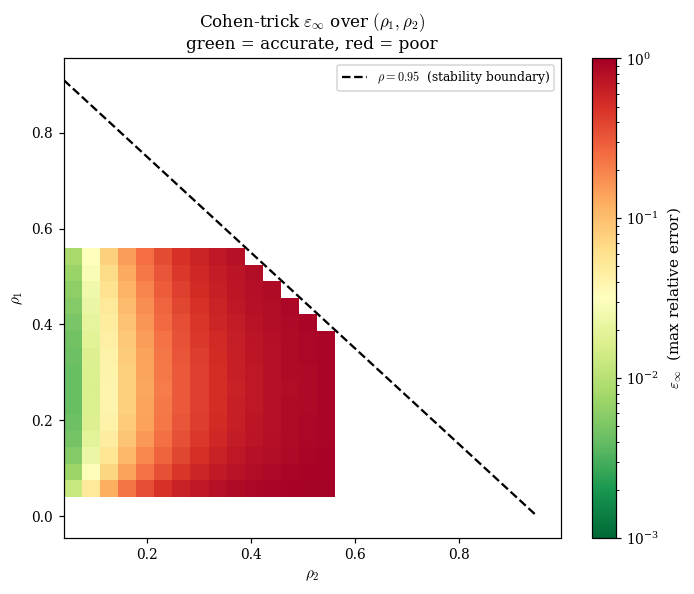

In [11]:
# ── Quick error summary across the parameter space ────────────────────────────

def approx_eps(p, n_max=45, y_grid=None, n_values=None):
    if y_grid  is None: y_grid  = np.linspace(0.0, 0.97, 80)
    if n_values is None: n_values = np.arange(1, 14)
    r  = solve_exact_tilde(p, n_max=n_max)
    pt = r["pi_tilde"]
    e  = np.zeros((len(n_values), len(y_grid)))
    for i, n in enumerate(n_values):
        ex  = P_tilde(y_grid, n, pt)
        ap  = P_tilde_approx_modelA(y_grid, n, p)
        msk = ex > 1e-14
        e[i, msk] = np.abs(ap[msk] - ex[msk]) / ex[msk]
    return float(e.max()), float(np.sqrt((e**2).mean()))

mu_v = 1.0
rho1_v = np.linspace(0.04, 0.56, 15)
rho2_v = np.linspace(0.04, 0.56, 15)
ei_2D  = np.full((len(rho1_v), len(rho2_v)), np.nan)

for i, r1 in enumerate(rho1_v):
    for j, r2 in enumerate(rho2_v):
        if r1 + r2 >= 0.97: continue
        ei_2D[i, j], _ = approx_eps(Params(r1*mu_v, r2*mu_v, mu_v))

fig, ax = plt.subplots(figsize=(6.5, 5.5))
ext = [rho2_v[0], rho2_v[-1], rho1_v[0], rho1_v[-1]]
im  = ax.imshow(ei_2D, origin="lower", extent=ext, aspect="auto",
                cmap="RdYlGn_r", norm=LogNorm(vmin=1e-3, vmax=1.0))
plt.colorbar(im, ax=ax, label=r"$\varepsilon_\infty$  (max relative error)")
ax.plot(np.linspace(rho2_v[0], 0.95, 100),
        0.95 - np.linspace(rho2_v[0], 0.95, 100), "k--", lw=1.5,
        label=r"$\rho=0.95$  (stability boundary)")
ax.set_xlabel(r"$\rho_2$"); ax.set_ylabel(r"$\rho_1$")
ax.set_title(r"Cohen-trick $\varepsilon_\infty$ over $(\rho_1, \rho_2)$"
             "\ngreen = accurate, red = poor")
ax.legend(fontsize=8)
fig.tight_layout()

In [12]:
# ── Summary table ─────────────────────────────────────────────────────────────

configs = [
    ("Light load, balanced",     Params(0.20, 0.20, 1.0)),
    ("Light, prio heavy",        Params(0.30, 0.10, 1.0)),
    ("Light, prio light",        Params(0.10, 0.30, 1.0)),
    ("Medium, balanced",         Params(0.30, 0.35, 1.0)),
    ("Medium, prio heavy",       Params(0.45, 0.20, 1.0)),
    ("Medium, prio light",       Params(0.15, 0.50, 1.0)),
    ("Heavy, balanced",          Params(0.40, 0.45, 1.0)),
    ("Heavy, prio heavy",        Params(0.60, 0.25, 1.0)),
    ("Heavy, prio light",        Params(0.20, 0.70, 1.0)),
]

print(f"{'Configuration':<26} {'rho':>5} {'r1/r':>6} {'eps_inf':>9} {'eps_L2':>9} {'quality':>10}")
print("─" * 68)
for name, pm in configs:
    ei, eL = approx_eps(pm)
    q = "excellent" if ei < 0.03 else ("good" if ei < 0.10 else ("fair" if ei < 0.30 else "poor"))
    print(f"{name:<26} {pm.rho:>5.2f} {pm.rho1/pm.rho:>6.2f} {ei:>9.4f} {eL:>9.4f} {q:>10}")

print()
print("Accurate (eps_inf < 10%) when rho1/rho > 0.60 and rho < 0.60.")
print("The approximation ALWAYS agrees at y=1 (total queue marginal is M/M/1 geometric).")

Configuration                rho   r1/r   eps_inf    eps_L2    quality
────────────────────────────────────────────────────────────────────
Light load, balanced        0.40   0.50    0.1630    0.0984       fair
Light, prio heavy           0.40   0.75    0.0298    0.0207  excellent
Light, prio light           0.40   0.25    0.5228    0.2894       poor
Medium, balanced            0.65   0.46    0.5571    0.2985       poor
Medium, prio heavy          0.65   0.69    0.2059    0.1157       fair
Medium, prio light          0.65   0.23    0.8657    0.5327       poor
Heavy, balanced             0.85   0.47    0.8056    0.4543       poor
Heavy, prio heavy           0.85   0.71    0.4913    0.2437       poor
Heavy, prio light           0.90   0.22    0.9717    0.6917       poor

Accurate (eps_inf < 10%) when rho1/rho > 0.60 and rho < 0.60.
The approximation ALWAYS agrees at y=1 (total queue marginal is M/M/1 geometric).


### Summary: approximation quality

| Condition | $\varepsilon_\infty$ |
|---|---|
| $\rho \le 0.4$, $\rho_1/\rho \ge 0.6$ | $< 3\%$ — excellent |
| $\rho \le 0.6$, $\rho_1/\rho \ge 0.6$ | $< 10\%$ — good |
| $\rho_1/\rho < 0.3$ or $\rho > 0.8$ | $> 30\%$ — poor |

The approximation underestimates $\widetilde{P}(y,n)$ for $y<1$
(dropped term is positive), is exact at $y=1$, and its error decays
geometrically in $n$ (since the inhomogeneous term $\sim\widetilde{\pi}(n,n)\sim\rho^n$).